<a href="https://colab.research.google.com/github/rithishdev/DL_Lab/blob/main/DL_Exp02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  24BAD099 - Rithish A

## PART A: VISUALIZATION OF ACTIVATION FUNCTIONS

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

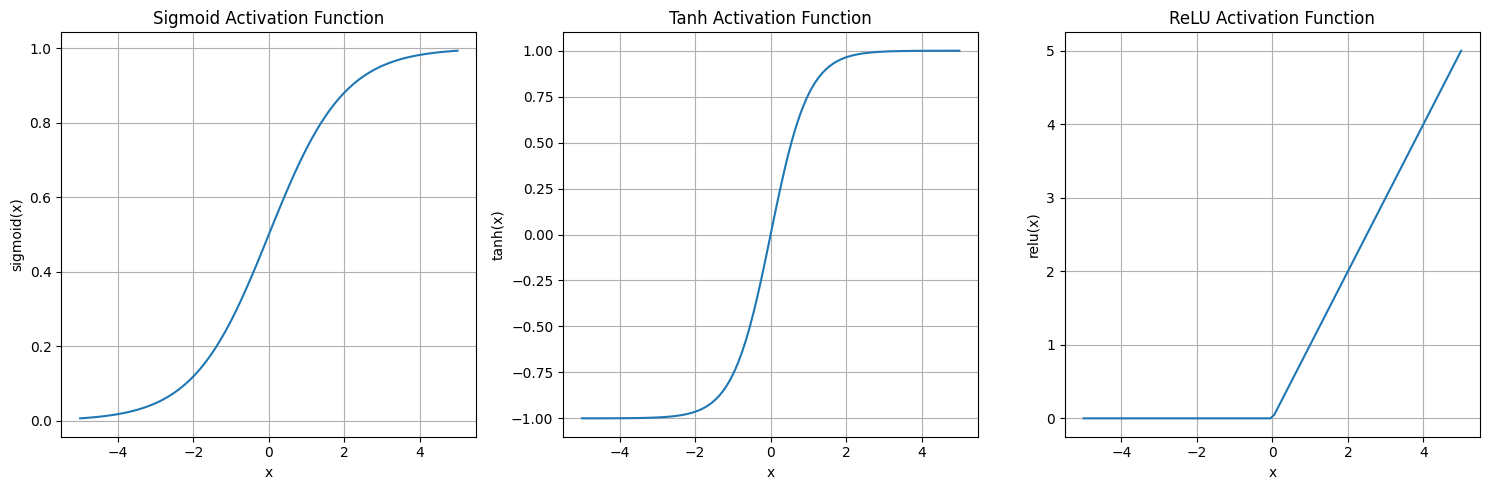

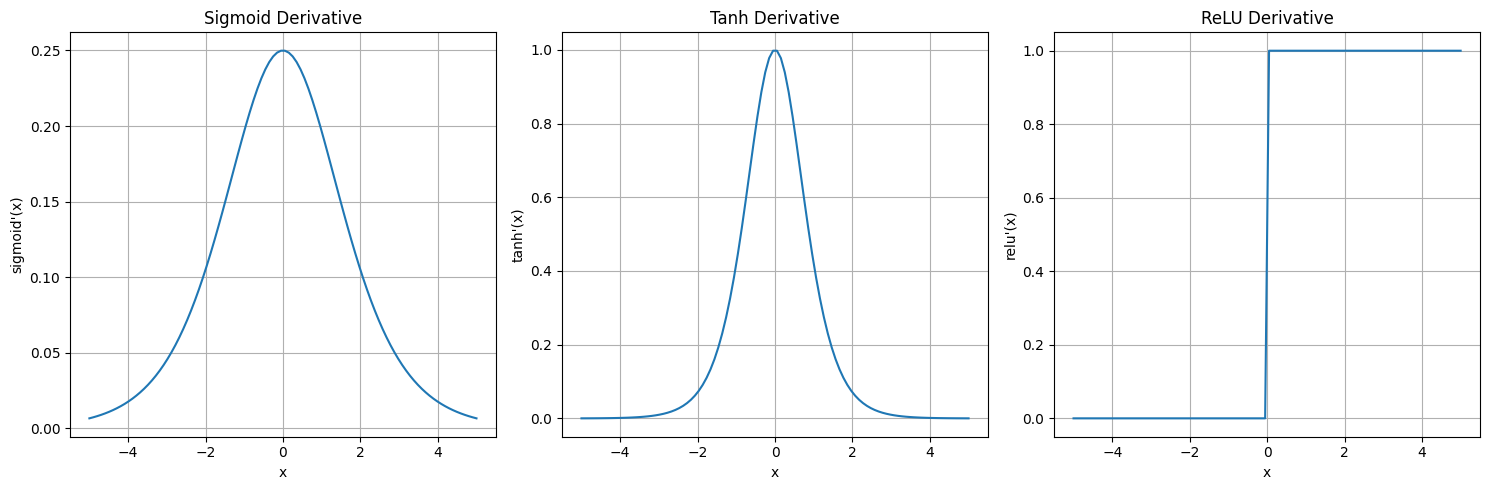

In [2]:
# Generate a range of values
x = np.linspace(-5, 5, 100)

# Plotting the activation functions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x))
plt.title('Sigmoid Activation Function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, tanh(x))
plt.title('Tanh Activation Function')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu(x))
plt.title('ReLU Activation Function')
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting the derivatives
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid_derivative(x))
plt.title('Sigmoid Derivative')
plt.xlabel('x')
plt.ylabel("sigmoid'(x)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, tanh_derivative(x))
plt.title('Tanh Derivative')
plt.xlabel('x')
plt.ylabel("tanh'(x)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu_derivative(x))
plt.title('ReLU Derivative')
plt.xlabel('x')
plt.ylabel("relu'(x)")
plt.grid(True)

plt.tight_layout()
plt.show()


## PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = '/content/breast-cancer.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    print("Please ensure 'breast-cancer.csv' is uploaded to /content/.")
    exit()

# Display basic information about the dataset
print(df.info())
print(df.head())

# Separate features and target variable
# Assuming the last column is the target and the first column is ID which might not be needed
# Drop 'id' column if it exists and is not a feature
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Assuming the 'diagnosis' column is the target variable
if 'diagnosis' in df.columns:
    X = df.drop('diagnosis', axis=1)
    y = df['diagnosis']
else:
    # If 'diagnosis' is not found, assume the last column is the target
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    print("Warning: 'diagnosis' column not found, assuming last column as target.")

# Encode target variable if it's categorical (e.g., 'M'/'B' for malignant/benign)
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"Target variable encoded: {le.classes_} -> {np.unique(y)}")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 1

In [4]:
# Function to create a model with a specified activation function
def create_model(activation_function, input_dim):
    model = Sequential([
        Dense(64, activation=activation_function, input_shape=(input_dim,)),
        Dense(32, activation=activation_function),
        Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Get input dimension
input_dim = X_train.shape[1]

# Train model with Sigmoid activation
print("\n--- Training with Sigmoid Activation ---")
sigmoid_model = create_model('sigmoid', input_dim)
sigmoid_history = sigmoid_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Train model with Tanh activation
print("\n--- Training with Tanh Activation ---")
tanh_model = create_model('tanh', input_dim)
tanh_history = tanh_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Train model with ReLU activation
print("\n--- Training with ReLU Activation ---")
relu_model = create_model('relu', input_dim)
relu_history = relu_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate models on the test set
sigmoid_loss, sigmoid_acc = sigmoid_model.evaluate(X_test, y_test, verbose=0)
tanh_loss, tanh_acc = tanh_model.evaluate(X_test, y_test, verbose=0)
relu_loss, relu_acc = relu_model.evaluate(X_test, y_test, verbose=0)

print(f"\nSigmoid Test Accuracy: {sigmoid_acc:.4f}, Test Loss: {sigmoid_loss:.4f}")
print(f"Tanh Test Accuracy: {tanh_acc:.4f}, Test Loss: {tanh_loss:.4f}")
print(f"ReLU Test Accuracy: {relu_acc:.4f}, Test Loss: {relu_loss:.4f}")


--- Training with Sigmoid Activation ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training with Tanh Activation ---

--- Training with ReLU Activation ---

Sigmoid Test Accuracy: 0.9825, Test Loss: 0.0636
Tanh Test Accuracy: 0.9737, Test Loss: 0.0871
ReLU Test Accuracy: 0.9737, Test Loss: 0.1013


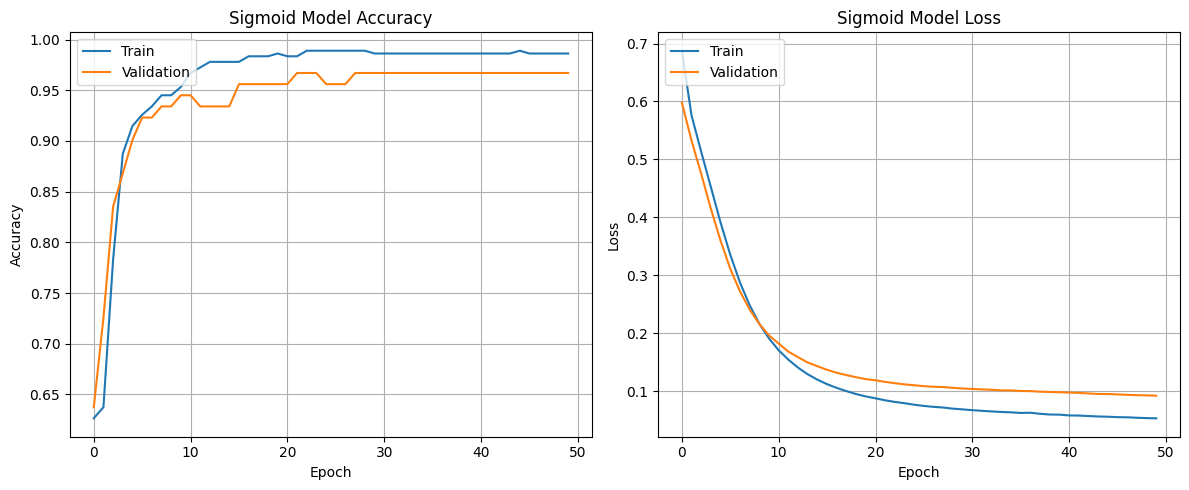

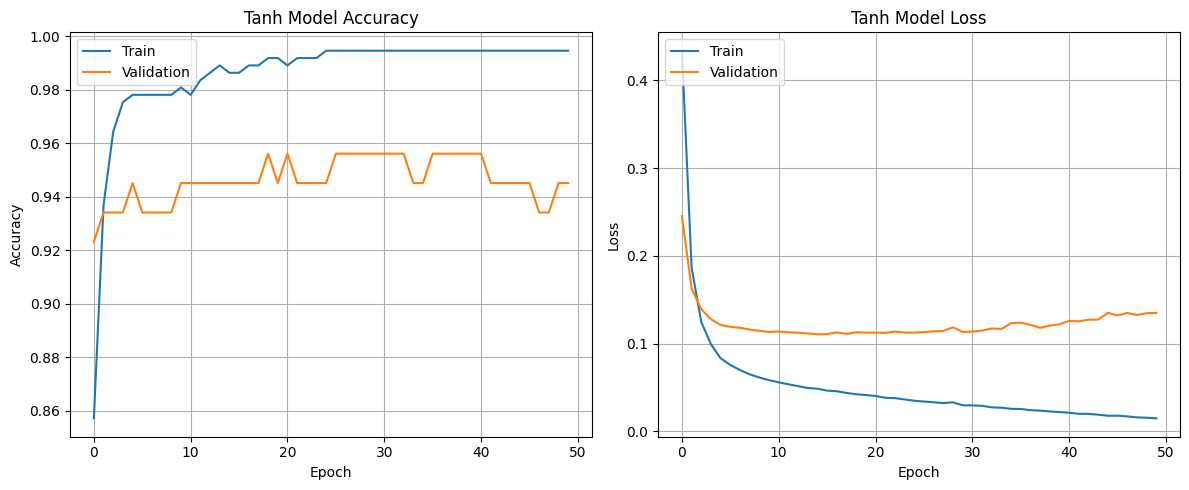

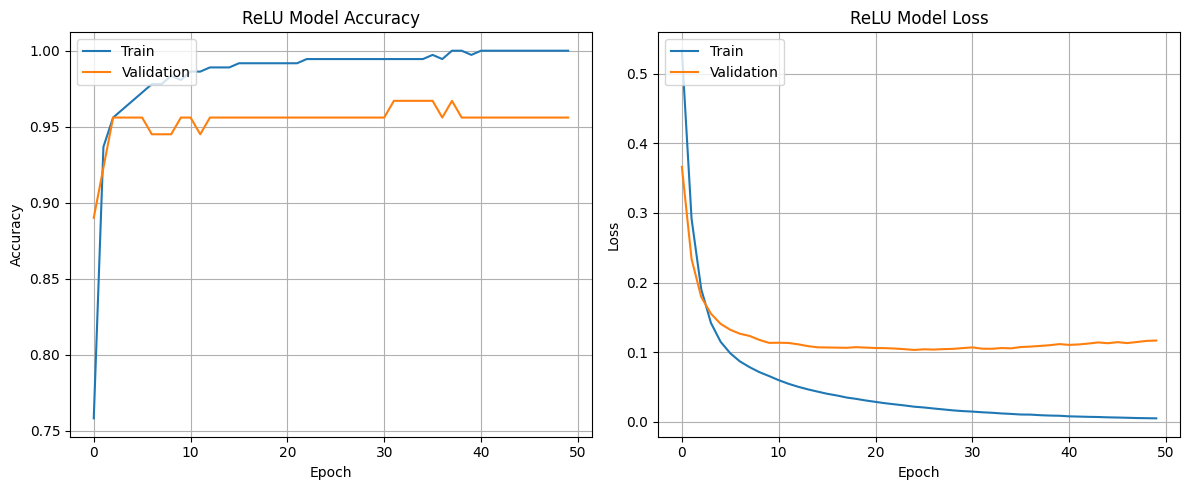


--- Sigmoid Results ---
Final Training Accuracy: 0.9863
Final Validation Accuracy: 0.9670
Final Training Loss: 0.0528
Final Validation Loss: 0.0919
Test Accuracy: 0.9825
Test Loss: 0.0636
Epochs trained: 50

--- Tanh Results ---
Final Training Accuracy: 0.9945
Final Validation Accuracy: 0.9451
Final Training Loss: 0.0149
Final Validation Loss: 0.1350
Test Accuracy: 0.9737
Test Loss: 0.0871
Epochs trained: 50

--- ReLU Results ---
Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9560
Final Training Loss: 0.0050
Final Validation Loss: 0.1168
Test Accuracy: 0.9737
Test Loss: 0.1013
Epochs trained: 50


In [5]:
# Function to plot history
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot histories for each model
plot_history(sigmoid_history, 'Sigmoid')
plot_history(tanh_history, 'Tanh')
plot_history(relu_history, 'ReLU')

# Summarize and compare results
def summarize_results(name, history, test_acc, test_loss):
    print(f"\n--- {name} Results ---")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    # Number of epochs for convergence (approximate, based on full training run)
    print(f"Epochs trained: {len(history.history['accuracy'])}")

summarize_results('Sigmoid', sigmoid_history, sigmoid_acc, sigmoid_loss)
summarize_results('Tanh', tanh_history, tanh_acc, tanh_loss)
summarize_results('ReLU', relu_history, relu_acc, relu_loss)


## PART C: COMPARISON OF OPTIMIZATION ALGORITHMS

In [8]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# Function to create a model with a specified optimizer
def create_model_with_optimizer(optimizer, input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)), # Using ReLU as it performed well
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Get input dimension (from Part B preprocessing)
# input_dim = X_train.shape[1] is already defined

# --- Train with different optimizers ---

# SGD
print("\n--- Training with SGD Optimizer ---")
sgd_optimizer = SGD(learning_rate=0.01)
sgd_model = create_model_with_optimizer(sgd_optimizer, input_dim)
sgd_history = sgd_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Momentum
print("\n--- Training with SGD (Momentum) Optimizer ---")
momentum_optimizer = SGD(learning_rate=0.01, momentum=0.9)
momentum_model = create_model_with_optimizer(momentum_optimizer, input_dim)
momentum_history = momentum_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# RMSProp
print("\n--- Training with RMSProp Optimizer ---")
rmsprop_optimizer = RMSprop(learning_rate=0.001)
rmsprop_model = create_model_with_optimizer(rmsprop_optimizer, input_dim)
rmsprop_history = rmsprop_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Adam
print("\n--- Training with Adam Optimizer ---")
adam_optimizer = Adam(learning_rate=0.001)
adam_model = create_model_with_optimizer(adam_optimizer, input_dim)
adam_history = adam_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# --- Evaluate models on the test set ---
sgd_loss, sgd_acc = sgd_model.evaluate(X_test, y_test, verbose=0)
momentum_loss, momentum_acc = momentum_model.evaluate(X_test, y_test, verbose=0)
rmsprop_loss, rmsprop_acc = rmsprop_model.evaluate(X_test, y_test, verbose=0)
adam_loss, adam_acc = adam_model.evaluate(X_test, y_test, verbose=0)

print(f"\nSGD Test Accuracy: {sgd_acc:.4f}, Test Loss: {sgd_loss:.4f}")
print(f"Momentum Test Accuracy: {momentum_acc:.4f}, Test Loss: {momentum_loss:.4f}")
print(f"RMSProp Test Accuracy: {rmsprop_acc:.4f}, Test Loss: {rmsprop_loss:.4f}")
print(f"Adam Test Accuracy: {adam_acc:.4f}, Test Loss: {adam_loss:.4f}")


--- Training with SGD Optimizer ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training with SGD (Momentum) Optimizer ---

--- Training with RMSProp Optimizer ---

--- Training with Adam Optimizer ---

SGD Test Accuracy: 0.9649, Test Loss: 0.0775
Momentum Test Accuracy: 0.9561, Test Loss: 0.1040
RMSProp Test Accuracy: 0.9825, Test Loss: 0.1675
Adam Test Accuracy: 0.9649, Test Loss: 0.1274


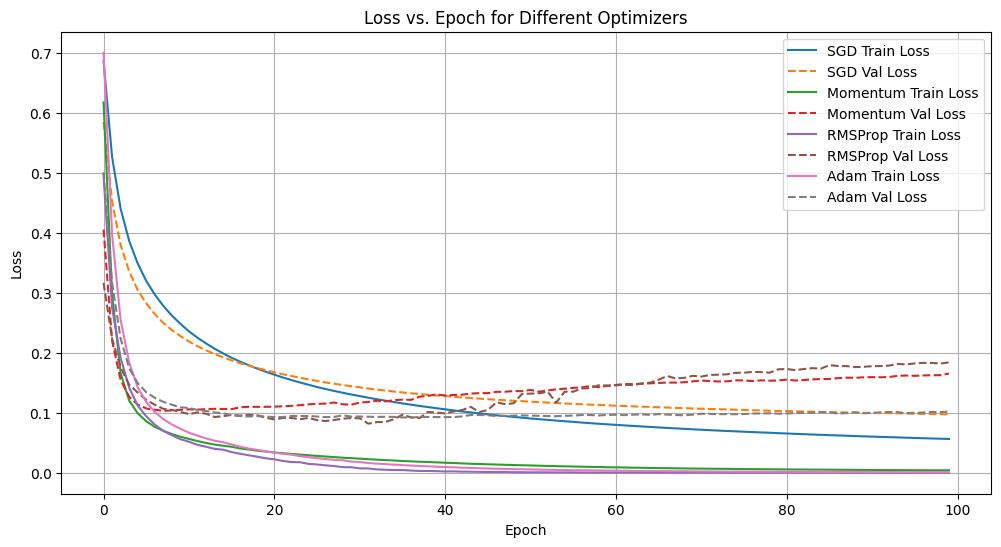

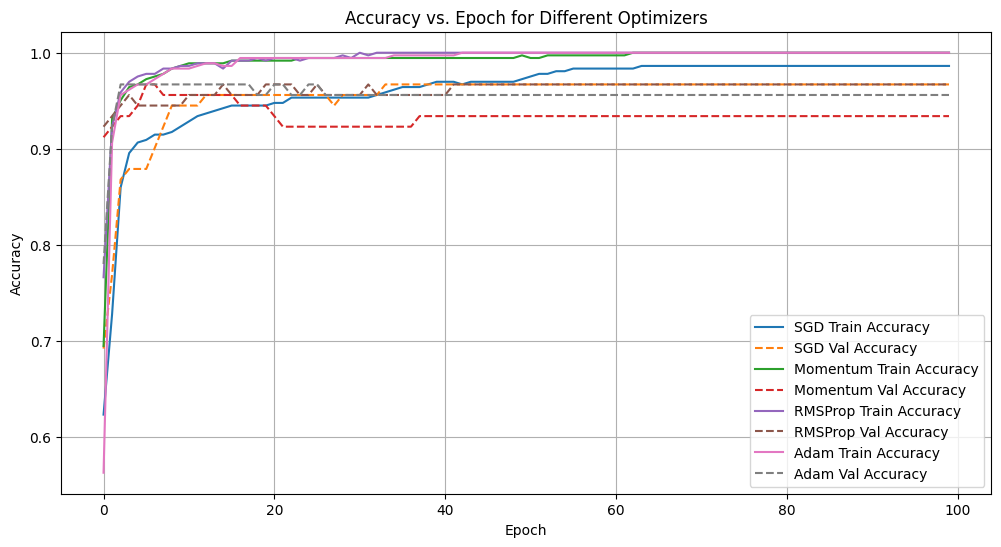


--- SGD Optimizer Results ---
Final Training Accuracy: 0.9863
Final Validation Accuracy: 0.9670
Final Training Loss: 0.0563
Final Validation Loss: 0.0973
Test Accuracy: 0.9649
Test Loss: 0.0775
Epochs trained: 100

--- Momentum Optimizer Results ---
Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9341
Final Training Loss: 0.0041
Final Validation Loss: 0.1654
Test Accuracy: 0.9561
Test Loss: 0.1040
Epochs trained: 100

--- RMSProp Optimizer Results ---
Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9670
Final Training Loss: 0.0001
Final Validation Loss: 0.1840
Test Accuracy: 0.9825
Test Loss: 0.1675
Epochs trained: 100

--- Adam Optimizer Results ---
Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.9560
Final Training Loss: 0.0009
Final Validation Loss: 0.1019
Test Accuracy: 0.9649
Test Loss: 0.1274
Epochs trained: 100


In [9]:
# Plotting Loss vs Epoch for all optimizers
plt.figure(figsize=(12, 6))
plt.plot(sgd_history.history['loss'], label='SGD Train Loss')
plt.plot(sgd_history.history['val_loss'], label='SGD Val Loss', linestyle='--')
plt.plot(momentum_history.history['loss'], label='Momentum Train Loss')
plt.plot(momentum_history.history['val_loss'], label='Momentum Val Loss', linestyle='--')
plt.plot(rmsprop_history.history['loss'], label='RMSProp Train Loss')
plt.plot(rmsprop_history.history['val_loss'], label='RMSProp Val Loss', linestyle='--')
plt.plot(adam_history.history['loss'], label='Adam Train Loss')
plt.plot(adam_history.history['val_loss'], label='Adam Val Loss', linestyle='--')
plt.title('Loss vs. Epoch for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy vs Epoch for all optimizers
plt.figure(figsize=(12, 6))
plt.plot(sgd_history.history['accuracy'], label='SGD Train Accuracy')
plt.plot(sgd_history.history['val_accuracy'], label='SGD Val Accuracy', linestyle='--')
plt.plot(momentum_history.history['accuracy'], label='Momentum Train Accuracy')
plt.plot(momentum_history.history['val_accuracy'], label='Momentum Val Accuracy', linestyle='--')
plt.plot(rmsprop_history.history['accuracy'], label='RMSProp Train Accuracy')
plt.plot(rmsprop_history.history['val_accuracy'], label='RMSProp Val Accuracy', linestyle='--')
plt.plot(adam_history.history['accuracy'], label='Adam Train Accuracy')
plt.plot(adam_history.history['val_accuracy'], label='Adam Val Accuracy', linestyle='--')
plt.title('Accuracy vs. Epoch for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Summarize and compare results for optimizers
def summarize_optimizer_results(name, history, test_acc, test_loss):
    print(f"\n--- {name} Optimizer Results ---")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Epochs trained: {len(history.history['accuracy'])}")

summarize_optimizer_results('SGD', sgd_history, sgd_acc, sgd_loss)
summarize_optimizer_results('Momentum', momentum_history, momentum_acc, momentum_loss)
summarize_optimizer_results('RMSProp', rmsprop_history, rmsprop_acc, rmsprop_loss)
summarize_optimizer_results('Adam', adam_history, adam_acc, adam_loss)